# Run Reactive Transport Model
This notebook is an example of how to set up a reactive transport model using a fairly complex carbon reaction network.

In [1]:
import potions as pt
from potions.hydro_model import HydrologicalModel
import pandas as pd
from pandas import DataFrame, Series
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.axes import Axes

## Load data

In [2]:
input_data_path: str = "../input/Sleepers_Results.txt"
df: DataFrame = pd.read_csv(input_data_path, sep=r"\s+", index_col=0, parse_dates=True)

precip_ser: Series = df["Precipitation"]
temp_ser: Series = df["Temperature"]
pet_ser: Series = df["PET"]
meas_streamflow: Series = df["Qobs"]

forc = pt.ForcingData(precip=precip_ser, temp=temp_ser, pet=pet_ser)

## The reaction network
The reaction network used in this example includes both kinetic and equilibrium reactions. For the equilibrium reactions, there are both aqueous equilibrium as well as adsorption reactions.

### Kinetic Reactions
The main kinetic reaction in this model is the respiration of solid organic carbon ($SOC_{(s)}$) in the soil into dissolved organic carbon (DOC) and dissolved inorganic carbon (DIC). This reaction looks like:
$$
SOC_{(s)} \to a\text{DOC} + b\text{DIC}
$$
Here, we use the placeholders $a$ and $b$ for the proportions of DOC and DIC because we might not know yet what they are.

### Equilibrium Reactions
The two types of equilibrium reactions in this network are aqueous equilibrium reactions and adsorption reactions. The aqueous reactions both carbonate species:
$$
\begin{aligned}
CO_{2(aq)} &\leftrightarrow H^+ HCO_3^- \\
HCO_3^- &\leftrightarrow H^+ CO_3^{2-} \\
\end{aligned}
$$

The mineral adsorption reaction involves DOC adsorbing onto mineral surfaces:
$$
X\text{DOC} \leftrightarrow X^- + DOC
$$

In practical terms, each of these species is categorized into a type based on its placement in the chemical database. The species types in this simulation are:
- **Primary**: $DOC$, $HCO_3^-$, $H^+$
- **Secondary**: $CO_3^{2-}$, $CO_{2(aq)}$
- **Minerals**: $SOC(s)$
- **Adsorption**: $X^{-}$, $XDOC$

In [3]:
db = pt.ChemicalDatabase.load_default()

In [4]:
primary_names: list[str] = ["DOC", "H+", "HCO3-"]
secondary_names: list[str] = ["CO3--", "CO2(aq)"]
mineral_names: list[str] = ["SOC(s)"]
adsorption_names: list[str] = ["XDOC"]
primary_species = db.get_primary_aqueous_species(primary_names)
secondary_species = db.get_secondary_species(secondary_names)
mineral_species = db.get_mineral_species(mineral_names)
mineral_kinetics = db.get_mineral_reactions(
    mineral_names=mineral_names, labels=["test"]
)
adsorption_species = db.get_exchange_reactions(adsorption_names)
# adsorption_species = []

In [5]:
network = pt.ReactionNetwork(
    primary_aqueous=primary_species,
    secondary=secondary_species,
    mineral=mineral_species,
    mineral_kinetics=mineral_kinetics,
    exchange_species=adsorption_species,
)

## Set up the model

### Create the Reactive transport zones

In [6]:
surface_soc_params = pt.MineralAuxParams(
    ssa=1.0, sw_threshold=0.5, sw_exp=1.0, q_10=1.5
)
shallow_soc_params = pt.MineralAuxParams(
    ssa=0.1, sw_threshold=0.5, sw_exp=1.0, q_10=1.0
)
deep_soc_params = pt.MineralAuxParams(ssa=1e-2, sw_threshold=0.5, sw_exp=0.0, q_10=1.0)

surface_min_params = pt.MineralParameters.from_mineral_parameters([surface_soc_params])
shallow_min_params = pt.MineralParameters.from_mineral_parameters([shallow_soc_params])
deep_min_params = pt.MineralParameters.from_mineral_parameters([deep_soc_params])

zone_dimensions = pt.ZoneDimensions(
    porosity=0.5, depth=1_000, passive_water_storage=0  # Depth, in millimeters
)

snow_zone_params = pt.RtParameters(dimensions=zone_dimensions, mineral_params=None)
surf_zone_params = pt.RtParameters(
    dimensions=zone_dimensions, mineral_params=surface_min_params
)
shallow_zone_params = pt.RtParameters(
    dimensions=zone_dimensions, mineral_params=shallow_min_params
)
deep_zone_params = pt.RtParameters(
    dimensions=zone_dimensions, mineral_params=deep_min_params
)

rt_params: dict[str, pt.RtParameters] = {
    "snow": snow_zone_params,
    "surface": surf_zone_params,
    "shallow": shallow_zone_params,
    "deep": deep_zone_params,
}

rt_model: dict[str, pt.RtZone] = {
    "snow": pt.RtZone(
        network,
        rt_params["snow"],
        do_reactions=False,
        do_speciation=False,
        name="snow",
    ),
    "surface": pt.RtZone(
        network, rt_params["surface"], name="surface", do_speciation=True
    ),
    "shallow": pt.RtZone(
        network, rt_params["shallow"], name="shallow", do_speciation=True
    ),
    "deep": pt.RtZone(network, rt_params["deep"], name="deep"),
}

zone_configs = {
    "snow": pt.RtZoneConfiguration(do_reactions=False, do_speciation=False),
    "surface": pt.RtZoneConfiguration(do_reactions=True, do_speciation=True),
    "shallow": pt.RtZoneConfiguration(do_reactions=True, do_speciation=True),
    "deep": pt.RtZoneConfiguration(do_reactions=True, do_speciation=True),
}
model = pt.HbvModel(rt_zones=rt_model, network=network, verbose=False)

In [7]:
precip_conc: np.ndarray = np.full(
    (model.num_surface_zones, len(forc.precip), len(network.species)),
    fill_value=1e-20,
    dtype=np.float64,
)

factor = 1.0

surface_init_state: pt.ChemicalState = pt.ChemicalState(
    mineral={"SOC(s)": factor * 1.0}, exchange={"X-": 1e-3}
)

shallow_init_state: pt.ChemicalState = pt.ChemicalState(
    mineral={"SOC(s)": factor * 0.1}, exchange={"X-": 1e-3}
)

deep_init_state: pt.ChemicalState = pt.ChemicalState(
    mineral={"SOC(s)": factor * 0.01}, exchange={"X-": 1e-3}
)

init_state = {
    "surface": surface_init_state,
    "shallow": shallow_init_state,
    "deep": deep_init_state,
}

In [8]:
network.exchange_species[0].name

'XDOC'

In [10]:
hydro_res = model.run_hydro_model(forc=forc, meas_streamflow=meas_streamflow)

try:
    rt_res = model.run_rt_model(
        # Forcing
        hydro_res=hydro_res,
        precip_conc=precip_conc.copy(),
        # Chemical state
        initial_state=init_state,
        # Other information
        verbose=False,
    )
    print("Finished simulation")
except Exception as e:
    err = e

initial state shape: (4, 8)
[[1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-20 1.e-20 1.e-06]
 [1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e+00 1.e-03 1.e-06]
 [1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-01 1.e-03 1.e-06]
 [1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-02 1.e-03 1.e-06]]
Finished simulation


In [11]:
river_dimensions: pt.RiverDimensions = pt.RiverDimensions(
    bed_depth=100.0, passive_water_storage=2.0
)
riv_soc_params = pt.MineralAuxParams(sw_threshold=1.0, sw_exp=0.0, q_10=1.0, ssa=0.1)
riv_min_params = pt.MineralParameters.from_mineral_parameters([riv_soc_params])
riv_params = pt.RiverParameters(
    dimensions=river_dimensions, mineral_params=riv_min_params
)

riv_zone = pt.RiverZone(
    network, params=riv_params, do_reactions=True, do_speciation=True, name="river"
)

In [12]:
forc_list: list[pt.HydroForcing] = [
    pt.HydroForcing(forc.precip.iloc[i], forc.temp.iloc[i], forc.pet.iloc[i], 0.0)
    for i in range(len(forc.precip))
]

In [13]:
rt_sim: DataFrame = rt_res.simulation
riv_conc_df = rt_sim[[c for c in rt_sim.columns if c.endswith("_riv")]]
riv_conc_arr = riv_conc_df.to_numpy()
sim_q: list[float] = hydro_res.simulation.sim_streamflow_mmd.tolist()

rt_forcings: list[pt.RtForcing] = []
for i, (c_i, q_i) in enumerate(zip(riv_conc_arr, sim_q)):
    f_i = pt.RtForcing(
        conc_in=c_i,
        hydro_step=pt.HydroStep(
            state=river_dimensions.passive_water_storage,
            forc_flux=0.0,
            lat_flux=q_i,
            vert_flux=0.0,
            vap_flux=0.0,
            q_in=q_i,
            lat_flux_ext=q_i,
            vert_flux_ext=0.0,
        ),
        hydro_forc=forc_list[i],
        s_w=1.0,
        z_w=0.0,
    )
    rt_forcings.append(f_i)

In [14]:
riv_init_state = np.full((network.num_species,), 1e-7, dtype=float)
riv_init_state[5] = 0.1  # SOC initial state
# riv_init_state[6] = 0.1  # X- initial state
c = riv_init_state
c_0 = riv_init_state
d = rt_forcings[0]

In [15]:
c = riv_init_state.copy()
riv_steps = []
concs: list[np.ndarray] = []

for i, rt_i in enumerate(rt_forcings):
    try:
        step = riv_zone.step(c, rt_i, dt_days=1.0)
        c = step.state.copy()
        concs.append(c.copy())
    except Exception:
        print(f"Got error on step {i} with c={c}")
        break

In [16]:
conc_arr = np.array(concs)
rc_df: DataFrame = DataFrame(
    data=conc_arr, columns=network.species_names, index=rt_sim.index
)

## Plot the results

In [17]:
plt.rcParams["figure.dpi"] = 300
plt.rcParams["legend.frameon"] = False
plt.rcParams["axes.spines.bottom"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.left"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlelocation"] = "left"

Text(0, 0.5, 'Conc. (mol/L)')

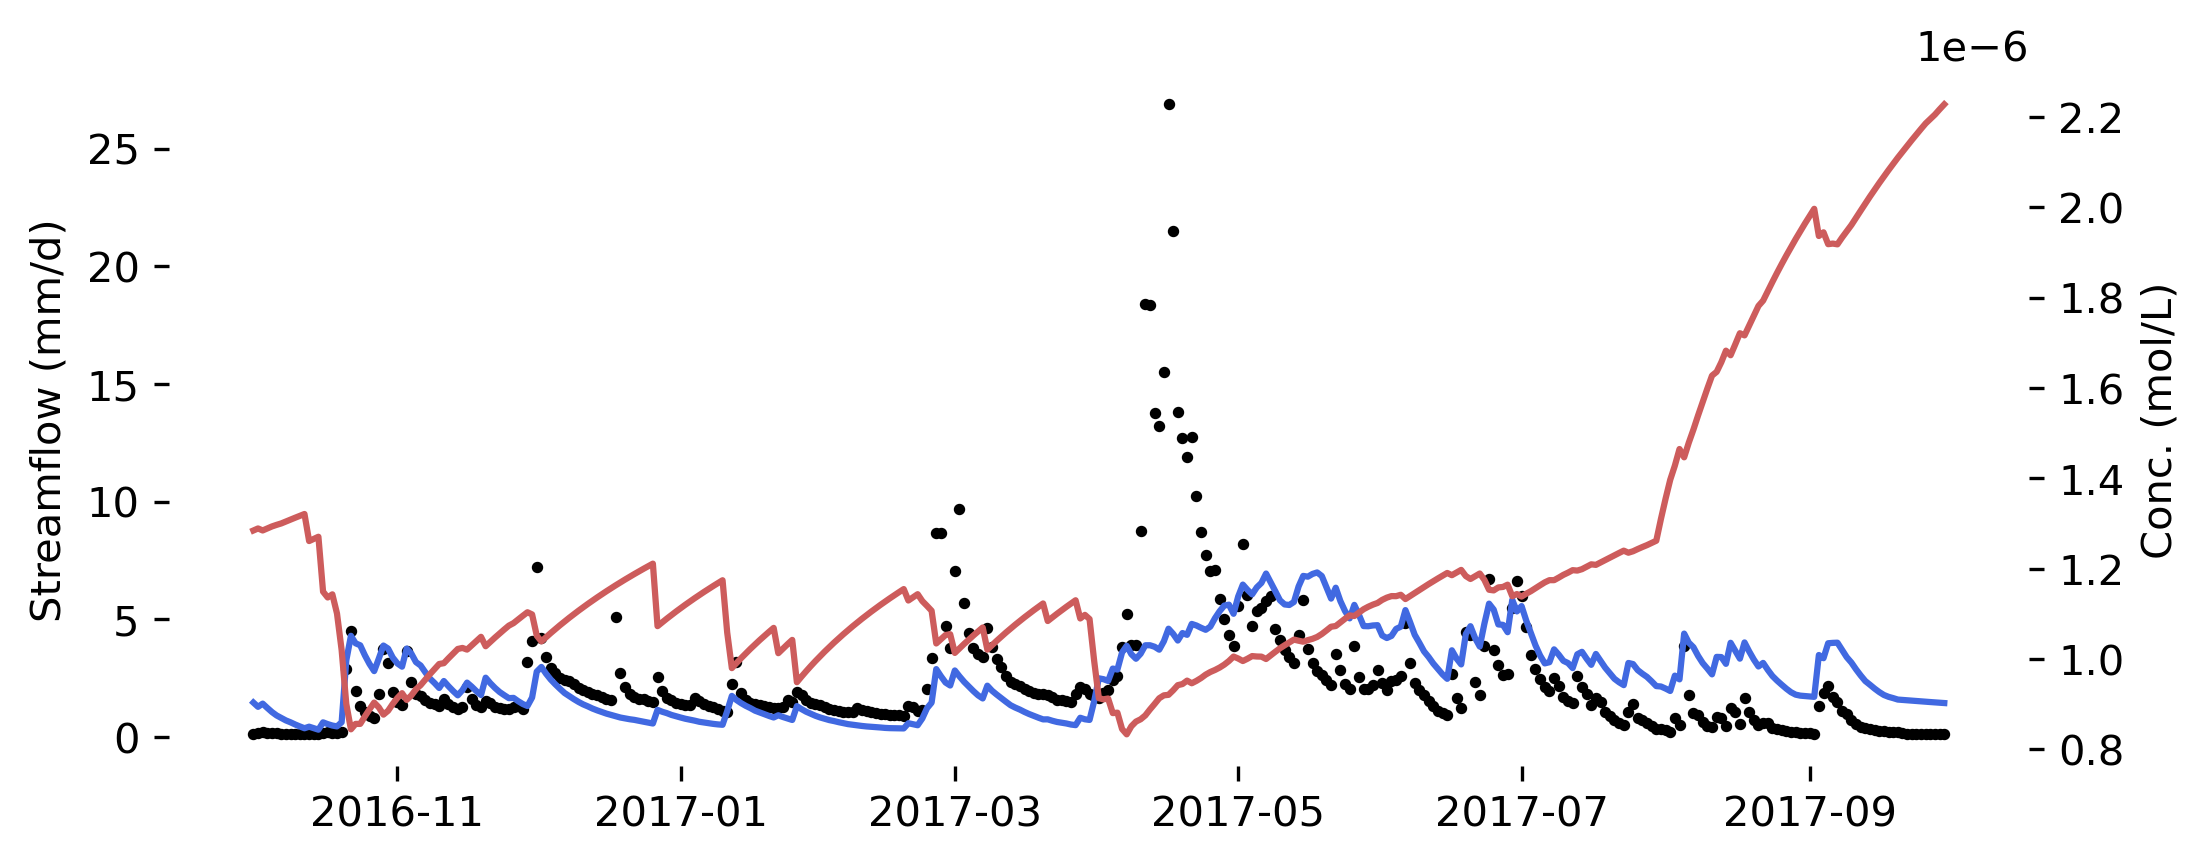

In [18]:
fig: Figure = plt.figure(figsize=(8, 3))
ax: Axes = fig.gca()

hr_df = hydro_res.simulation

ax.scatter(hr_df.index, hr_df["meas_streamflow_mmd"], color="black", s=3)
ax.plot(hr_df.index, hr_df["sim_streamflow_mmd"], color="royalblue")
ax.set_ylabel("Streamflow (mm/d)")

ax2 = ax.twinx()
ax2.plot(rt_sim["DOC_shallow"], color="indianred", label="Shallow")
ax2.set_ylabel("Conc. (mol/L)")

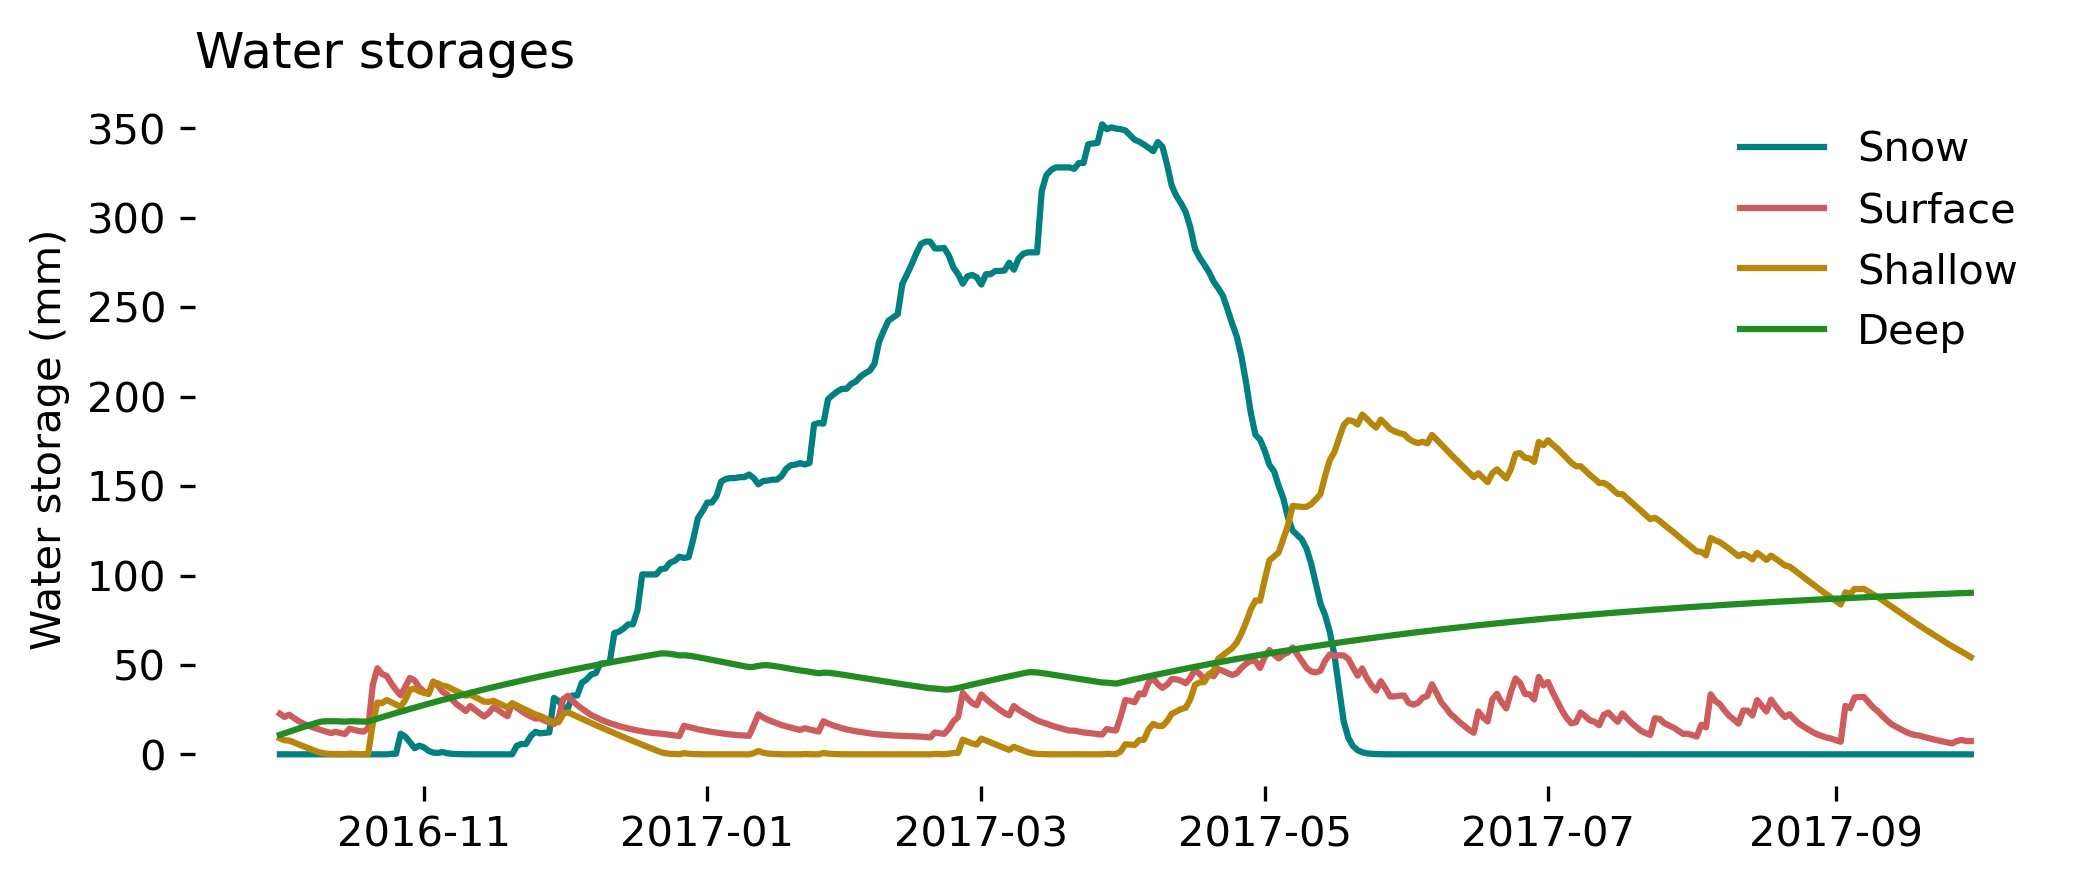

In [19]:
fig: Figure = plt.figure(figsize=(8, 3))
ax: Axes = fig.gca()

hr_df = hydro_res.simulation

ax.plot(hr_df.index, hr_df["s_snow"], color="teal", label="Snow")
ax.plot(hr_df.index, hr_df["s_surface"], color="indianred", label="Surface")
ax.plot(hr_df.index, hr_df["s_shallow"], color="darkgoldenrod", label="Shallow")
ax.plot(hr_df.index, hr_df["s_deep"], color="forestgreen", label="Deep")
ax.set_ylabel("Water storage (mm)")
ax.set_title("Water storages")
ax.legend()

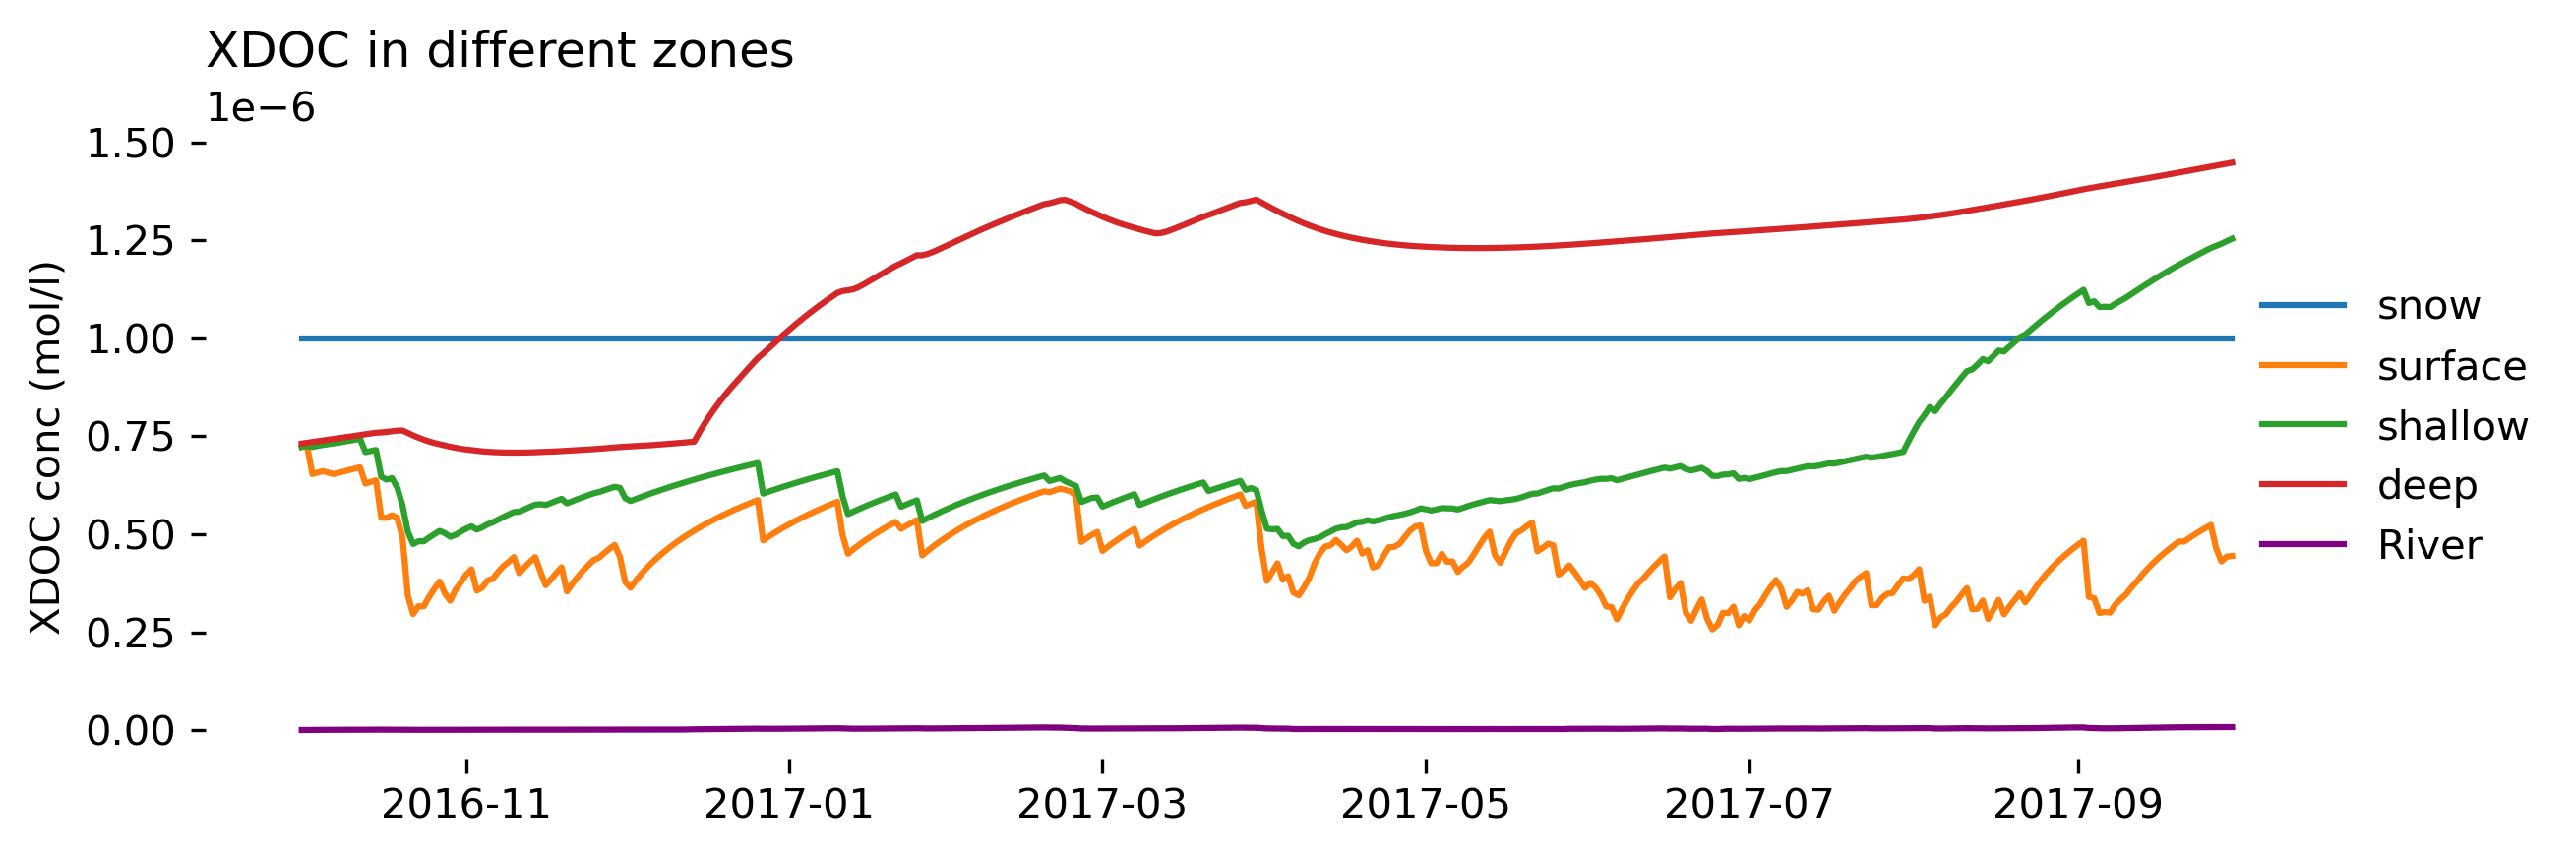

In [20]:
fig: Figure = plt.figure(figsize=(8, 3))
ax: Axes = fig.gca()

spec = "XDOC"

for zn in pt.HbvModel.get_zone_names():
    ax.plot(rt_sim.index, rt_sim[f"{spec}_{zn}"], label=zn)
    # ax.scatter(rt_sim.index, rt_sim)

ax.plot(rc_df.index, rc_df[spec], color="purple", label="River")
fig.legend(loc="center", bbox_to_anchor=(1.01, 0.5))

ax.set_ylabel(f"{spec} conc (mol/l)")
ax.set_title(f"{spec} in different zones")
fig.tight_layout()